In [116]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

In [117]:
df_usa = df[df['job_country']== 'United States'].copy()
df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.strftime('%B')
df_usa_pivot = df_usa.pivot_table( index = 'job_posted_month',
                                 columns = 'job_title_short',
                                 aggfunc = 'size')
df_usa_pivot.reset_index(inplace = True)


In [118]:
df_usa_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
0,April,565,40,6049,2801,4867,51,1025,781,991,112
1,August,903,39,6634,3269,6318,68,1186,903,1515,194
2,December,648,40,3979,2641,3472,119,601,689,752,212
3,February,447,24,6124,3060,4956,56,1258,878,1127,90
4,January,527,36,8494,2655,6915,60,1544,773,1552,114
5,July,581,39,5201,2570,4876,65,883,747,1095,153
6,June,446,32,5683,2893,4645,48,1009,812,1033,93
7,March,438,19,6218,3183,4779,59,1114,829,1150,115
8,May,279,20,4993,2976,4377,49,839,746,914,90
9,November,719,36,4531,2793,4175,132,656,684,816,194


In [119]:
df_usa_pivot['month_no.'] = pd.to_datetime(df_usa_pivot['job_posted_month'], format = '%B')
df_usa_pivot['month_no.'] = df_usa_pivot['month_no.'].dt.month

df_usa_pivot.sort_values(by = 'month_no.', ascending = True, inplace = True )


In [120]:
columns_needed = ('job_posted_month','Data Analyst', 'Data Scientist', 'Data Engineer')
df_usa_pivot = df_usa_pivot.loc[:, df_usa_pivot.columns.isin(columns_needed)]
df_usa_pivot.set_index('job_posted_month', inplace = True)


<function matplotlib.pyplot.show(close=None, block=None)>

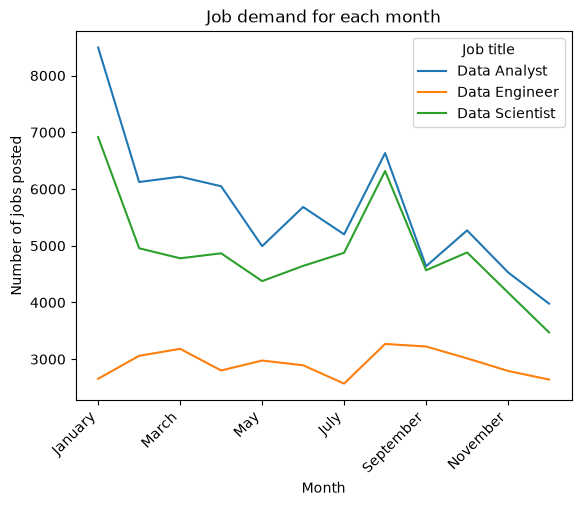

In [121]:
df_usa_pivot.plot(kind = 'line')
plt.xlabel('Month')
plt.ylabel('Number of jobs posted')
plt.title('Job demand for each month')
plt.xticks(rotation = 45 , ha = 'right')
plt.legend(title = 'Job title')
plt.show


In [122]:
help(dict)

Help on class dict in module builtins:

class dict(object)
 |  dict() -> new empty dictionary
 |  dict(mapping) -> new dictionary initialized from a mapping object's
 |      (key, value) pairs
 |  dict(iterable) -> new dictionary initialized as if via:
 |      d = {}
 |      for k, v in iterable:
 |          d[k] = v
 |  dict(**kwargs) -> new dictionary initialized with the name=value pairs
 |      in the keyword argument list.  For example:  dict(one=1, two=2)
 |
 |  Methods defined here:
 |
 |  __contains__(self, key, /)
 |      True if the dictionary has the specified key, else False.
 |
 |  __delitem__(self, key, /)
 |      Delete self[key].
 |
 |  __eq__(self, value, /)
 |      Return self==value.
 |
 |  __ge__(self, value, /)
 |      Return self>=value.
 |
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |
 |  __getitem__(self, key, /)
 |      Return self[key].
 |
 |  __gt__(self, value, /)
 |      Return self>value.
 |
 |  __init__(self, /, *args, **kwarg